# Sprint 2 — Perfilado Demográfico + Análisis Financiero + Acciones Comerciales
**Metodología:** K-Prototypes sobre variables demográficas → análisis financiero a posteriori por segmento → generación automática de perfil y acciones comerciales.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.io as pio
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

# Estilo Dark Mode Plotly
pio.templates.default = "plotly_dark"
pio.templates["custom"] = pio.templates["plotly_dark"]
pio.templates["custom"].layout.paper_bgcolor = "#050a30"
pio.templates["custom"].layout.plot_bgcolor  = "#050a30"
pio.templates.default = "custom"

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


## 1. Carga de Datos

In [2]:
import os
import glob

# Busqueda automatica del archivo en cualquier maquina
FILENAME = '06-01-2026_Clean.csv'

def encontrar_archivo(nombre):
    # 1. Mismo directorio que el notebook
    nb_dir = os.getcwd()
    ruta_local = os.path.join(nb_dir, nombre)
    if os.path.exists(ruta_local):
        return ruta_local

    # 2. Buscar recursivamente desde el home del usuario
    home = os.path.expanduser('~')
    resultados = glob.glob(os.path.join(home, '**', nombre), recursive=True)
    if resultados:
        return resultados[0]

    # 3. Buscar desde la raiz del disco (ultimo recurso, mas lento)
    import platform
    raiz = 'C:\\' if platform.system() == 'Windows' else '/'
    resultados = glob.glob(os.path.join(raiz, '**', nombre), recursive=True)
    if resultados:
        return resultados[0]

    return None


ruta = encontrar_archivo(FILENAME)

if ruta:
    print(f'Archivo encontrado en: {ruta}')
    df = pd.read_csv(ruta)
    print(f'Shape: {df.shape}')
else:
    raise FileNotFoundError(
        f'No se encontro {FILENAME}.\n'
        'Comprueba que el archivo este en el equipo y vuelve a ejecutar.'
    )

print('\nValores nulos:')
print(df.isna().sum())
df.head()


Archivo encontrado en: c:\Users\HP\OneDrive\Download\Desktop\Simulador\DESAFIO 2\06-01-2026_Clean.csv
Shape: (10987, 18)

Valores nulos:
id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,no_pcampaign,1
1,2,56,admin.,married,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,no_pcampaign,1
2,3,41,technician,married,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,no_pcampaign,1
3,4,55,services,married,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,no_pcampaign,1
4,5,54,admin.,married,tertiary,0,184,0,0,unknown,5,may,673,2,-1,0,no_pcampaign,1


## 2. Fase 1 — Perfilado Demográfico (K-Prototypes)
Se entrena el modelo usando **únicamente variables demográficas**: `age`, `job`, `marital`, `education`.

In [3]:
print("--- FASE 1: Perfilado Demográfico ---")

cuanti_d1 = ['age']
categ_d1  = ['job', 'marital', 'education']

df_d1 = df[cuanti_d1 + categ_d1].copy()

scaler_d1 = StandardScaler()
df_d1[cuanti_d1] = scaler_d1.fit_transform(df_d1[cuanti_d1])

X_d1           = df_d1.to_numpy()
cat_indices_d1 = [df_d1.columns.get_loc(col) for col in categ_d1]

kproto_d1 = KPrototypes(n_clusters=4, init='Cao', random_state=42, n_init=3)
df['cluster_demografico'] = kproto_d1.fit_predict(X_d1, categorical=cat_indices_d1)

print("✅ Perfiles demográficos asignados en 'cluster_demografico'.")
print("\nDistribución por segmento:")
print(df['cluster_demografico'].value_counts().sort_index())

--- FASE 1: Perfilado Demográfico ---
✅ Perfiles demográficos asignados en 'cluster_demografico'.

Distribución por segmento:
cluster_demografico
0    1800
1    3220
2    2802
3    3165
Name: count, dtype: int64


## 3. Fase 2 — Análisis Financiero por Segmento
**Sin re-entrenar el modelo.** Se analizan variables financieras sobre los segmentos ya formados.

In [4]:
print("--- FASE 2: Análisis Financiero por Segmento ---")

# Variable derivada: número de productos de deuda activos
# ⚠️ Se calcula sumando directamente las columnas ya numéricas (0 y 1)
df['active_loans_count'] = df['default'] + df['housing'] + df['loan']

cluster_col           = 'cluster_demografico'
variables_heatmap     = ['age', 'balance', 'active_loans_count']
variables_categoricas = ['job', 'marital', 'education']

# Medias reales por segmento
tabla_real = (
    df.groupby(cluster_col)[variables_heatmap]
    .mean()
    .round(2)
)

# Medias escaladas (para heatmap comparativo)
scaler_hm  = StandardScaler()
df_scaled  = pd.DataFrame(
    scaler_hm.fit_transform(df[variables_heatmap]),
    columns=variables_heatmap,
    index=df.index
)
df_scaled[cluster_col] = df[cluster_col]
tabla_escalada = df_scaled.groupby(cluster_col).mean().round(2)

# Moda demográfica por segmento
tabla_categorica = (
    df.groupby(cluster_col)[variables_categoricas]
    .agg(lambda x: x.mode()[0])
)

# Tasa de contratación de depósito por segmento
tabla_deposit = (
    df.groupby(cluster_col)['deposit']
    .mean()
    .round(3)
    .rename('tasa_deposit')
)

print("✅ Tablas financieras calculadas.")

--- FASE 2: Análisis Financiero por Segmento ---
✅ Tablas financieras calculadas.


## 4. Generación Automática de Perfil y Acciones Comerciales
La función lee los valores reales de cada segmento y genera el nombre del perfil y las acciones de forma automática.

In [5]:
def generar_nombre_segmento(seg_id, row_real, row_cat):
    """
    Genera un nombre corto y descriptivo para el segmento
    basado en etapa de vida y ocupación modal.
    Usado en impresiones, gráficos y exportación a Marketing.
    """
    age = row_real['age']
    job = row_cat['job']

    if age < 30:
        etapa = "Jóvenes"
    elif age < 45:
        etapa = "Activos"
    elif age < 60:
        etapa = "Consolidados"
    else:
        etapa = "Seniors"

    job_map = {
        'management':    'Directivos',
        'technician':    'Técnicos',
        'blue-collar':   'Operarios',
        'admin.':        'Administrativos',
        'services':      'Servicios',
        'retired':       'Jubilados',
        'self-employed': 'Autónomos',
        'entrepreneur':  'Emprendedores',
        'housemaid':     'Hogar',
        'student':       'Estudiantes',
        'unemployed':    'Desempleados',
        'unknown':       'Mixto'
    }
    ocupacion = job_map.get(job, job.capitalize())
    return f"{etapa} {ocupacion}"


def generar_perfil_y_acciones(seg_id, row_real, row_cat, tasa_dep):
    """
    Genera automáticamente el nombre del perfil y la acción comercial
    a partir de los datos agregados de cada segmento.
    """
    age     = row_real['age']
    balance = row_real['balance']
    loans   = row_real['active_loans_count']
    job     = row_cat['job']
    marital = row_cat['marital']

    nombre  = generar_nombre_segmento(seg_id, row_real, row_cat)

    # ── Etapa de vida ────────────────────────────────────────────────────────
    if age < 30:
        etapa = "Joven"
    elif age < 45:
        etapa = "Adulto en activo"
    elif age < 60:
        etapa = "Adulto senior"
    else:
        etapa = "Próximo a jubilación"

    # ── Estado financiero ────────────────────────────────────────────────────
    if balance > 2000 and loans < 0.5:
        estado_fin = "saldo sólido y sin deudas"
    elif balance > 1500 and loans < 1:
        estado_fin = "saldo sólido y bajo endeudamiento"
    elif balance > 1000 and loans <= 1.5:
        estado_fin = "saldo medio y endeudamiento moderado"
    elif balance <= 1000 and loans >= 1.5:
        estado_fin = "saldo bajo y alta carga de deuda"
    else:
        estado_fin = "perfil financiero mixto"

    perfil = f"{nombre} · {etapa} · {job} · {marital} · {estado_fin}"

    # ── Acciones comerciales ─────────────────────────────────────────────────
    acciones = []

    if tasa_dep < 0.35:
        acciones.append("Campaña agresiva: regalo por apertura de depósito")
    elif tasa_dep < 0.50:
        acciones.append("Oferta estándar: depósito a plazo con tasa competitiva")
    else:
        acciones.append("Fidelización: acceso a eventos exclusivos y asesor personal")

    if loans >= 1.2:
        acciones.append("Propuesta de consolidación de deudas")
    elif loans > 0.4:
        acciones.append("Oferta de tarjeta de crédito con beneficios o mejora de préstamo")
    else:
        acciones.append("Venta cruzada: ofrecer primer préstamo personal pre-aprobado")

    if balance > 3000:
        acciones.append("Gestión de patrimonio / Fondos de inversión de renta variable")
    elif balance > 1500:
        acciones.append("Plan de ahorro sistemático o seguro de vida-ahorro")
    elif balance < 500:
        acciones.append("Micro-créditos o adelanto de nómina")

    if age < 30:
        acciones.append("Fomentar uso de Bizum y pagos con móvil (Apple/Google Pay)")
    elif 30 <= age < 50:
        acciones.append("Seguros de hogar o salud familiar")
    else:
        acciones.append("Asesoramiento en herencias y productos de renta vitalicia")

    accion_str = " | ".join(acciones)
    return nombre, perfil, accion_str


# Construir tabla de acciones
registros = []
for seg_id in sorted(df[cluster_col].unique()):
    row_real = tabla_real.loc[seg_id]
    row_cat  = tabla_categorica.loc[seg_id]
    tasa     = tabla_deposit.loc[seg_id]
    nombre, perfil, accion = generar_perfil_y_acciones(seg_id, row_real, row_cat, tasa)
    registros.append({
        cluster_col:                    seg_id,
        'nombre_segmento':              nombre,
        'Perfil interpretado':          perfil,
        'Acción comercial recomendada': accion
    })

tabla_acciones = pd.DataFrame(registros).set_index(cluster_col)

# Mapear nombre al dataframe principal (para gráficos y exportación)
nombre_map = tabla_acciones['nombre_segmento'].to_dict()
df['nombre_segmento'] = df[cluster_col].map(nombre_map)

print("✅ Perfiles, nombres y acciones generados automáticamente.")
tabla_acciones[['nombre_segmento', 'Perfil interpretado', 'Acción comercial recomendada']]


✅ Perfiles, nombres y acciones generados automáticamente.


,nombre_segmento,Perfil interpretado,Acción comercial recomendada
cluster_demografico,,,
0,Seniors Jubilados,Seniors Jubilados · Próximo a jubilación · retired · married · saldo sólido y sin deudas,Fidelización: acceso a eventos exclusivos y asesor personal | Venta cruzada: ofrecer primer préstamo personal pre-aprobado | Plan de ahorro sistemático o seguro de vida-ahorro | Asesoramiento en herencias y productos de renta vitalicia
1,Activos Operarios,Activos Operarios · Adulto en activo · blue-collar · single · saldo medio y endeudamiento moderado,Fidelización: acceso a eventos exclusivos y asesor personal | Oferta de tarjeta de crédito con beneficios o mejora de préstamo | Seguros de hogar o salud familiar
2,Activos Directivos,Activos Directivos · Adulto en activo · management · married · saldo sólido y bajo endeudamiento,Oferta estándar: depósito a plazo con tasa competitiva | Oferta de tarjeta de crédito con beneficios o mejora de préstamo | Plan de ahorro sistemático o seguro de vida-ahorro | Seguros de hogar o salud familiar
3,Consolidados Técnicos,Consolidados Técnicos · Adulto senior · technician · married · saldo medio y endeudamiento moderado,Oferta estándar: depósito a plazo con tasa competitiva | Oferta de tarjeta de crédito con beneficios o mejora de préstamo | Seguros de hogar o salud familiar


## 5. Heatmaps — Comportamiento Financiero por Segmento

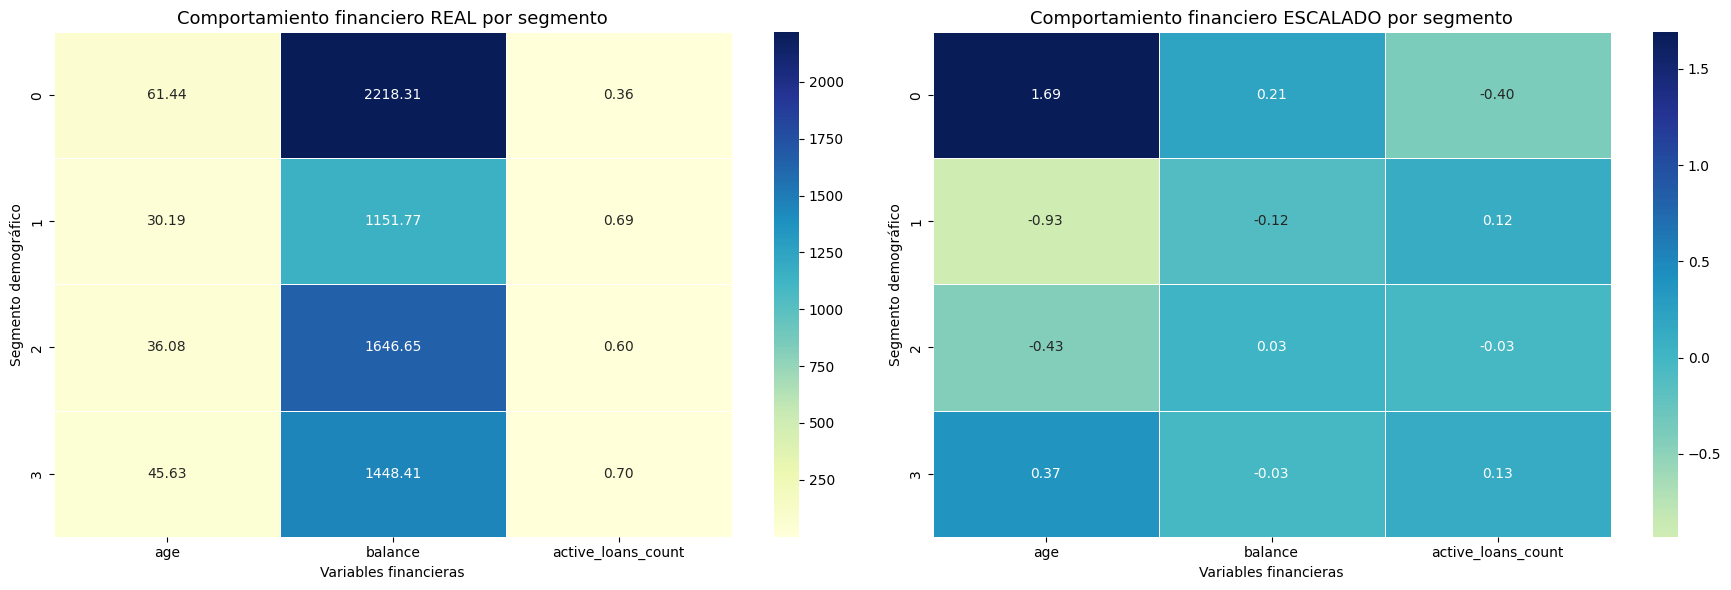

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(
    tabla_real,
    annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title('Comportamiento financiero REAL por segmento', fontsize=13)
axes[0].set_xlabel('Variables financieras')
axes[0].set_ylabel('Segmento demográfico')

sns.heatmap(
    tabla_escalada,
    annot=True, fmt='.2f', cmap='YlGnBu', center=0, linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title('Comportamiento financiero ESCALADO por segmento', fontsize=13)
axes[1].set_xlabel('Variables financieras')
axes[1].set_ylabel('Segmento demográfico')

plt.tight_layout()
plt.show()

## 6. Tabla Final Consolidada — Perfil + Financiero + Tasa Depósito + Acciones

In [7]:
tabla_perfil = pd.concat([tabla_real, tabla_categorica], axis=1)
tabla_final  = tabla_perfil.join(tabla_deposit).join(tabla_acciones)

# ── Ranking por tasa de conversión de depósito ───────────────────────────
tabla_final['ranking_deposit'] = (
    tabla_final['tasa_deposit']
    .rank(ascending=False, method='dense')
    .astype(int)
)

cols_orden = [
    'nombre_segmento',
    'ranking_deposit',
    'age', 'balance', 'active_loans_count',
    'job', 'marital', 'education',
    'tasa_deposit',
    'Perfil interpretado',
    'Acción comercial recomendada'
]

print("════════════ TABLA FINAL: PERFIL + FINANCIERO + ACCIONES ════════════")
display(tabla_final[cols_orden].sort_values('ranking_deposit'))

# ── Ranking limpio para Marketing ────────────────────────────────────────
tabla_marketing = (
    tabla_final[['nombre_segmento', 'tasa_deposit', 'ranking_deposit',
                 'age', 'balance', 'job', 'marital', 'education',
                 'Acción comercial recomendada']]
    .sort_values('ranking_deposit')
    .rename(columns={
        'nombre_segmento':              'Segmento',
        'tasa_deposit':                 'Tasa Conversión Depósito',
        'ranking_deposit':              'Prioridad',
        'age':                          'Edad Media',
        'balance':                      'Balance Medio',
        'job':                          'Ocupación',
        'marital':                      'Estado Civil',
        'education':                    'Educación',
        'Acción comercial recomendada': 'Acción Recomendada'
    })
)

print("\n════════════ RANKING PARA MARKETING (por conversión depósito) ════════════")
display(tabla_marketing)

# ── Impresión por segmento con nombre ────────────────────────────────────
print("\n" + "═"*70)
print("RESUMEN DE ACCIONES COMERCIALES POR SEGMENTO")
print("═"*70)
for index, row in tabla_final.sort_values('ranking_deposit').iterrows():
    print(f"\n▶ [{row['ranking_deposit']}] {row['nombre_segmento']} (Cluster {index})")
    print(f"  Perfil: {row['Perfil interpretado']}")
    print(f"  Tasa depósito: {row['tasa_deposit']:.1%}")
    print(f"  Acción Recomendada: {row['Acción comercial recomendada']}")
print("\n" + "═"*70)

# ── Exportar CSV para Marketing ──────────────────────────────────────────
tabla_marketing.to_csv('segmentos_para_marketing.csv', index=False)
print("\n✅ Exportado: segmentos_para_marketing.csv")

# ── Exportar clusters para cruce con Finanzas (índice = CSV clean) ───────
df[['cluster_demografico', 'nombre_segmento']].to_csv('clusters_perfil_cliente.csv', index=True)
print("✅ Exportado: clusters_perfil_cliente.csv (para cruce con Finanzas)")


════════════ TABLA FINAL: PERFIL + FINANCIERO + ACCIONES ════════════


,nombre_segmento,ranking_deposit,age,balance,active_loans_count,job,marital,education,tasa_deposit,Perfil interpretado,Acción comercial recomendada
cluster_demografico,,,,,,,,,,,
0,Seniors Jubilados,1,61.44,2218.31,0.36,retired,married,secondary,0.578,Seniors Jubilados · Próximo a jubilación · retired · married · saldo sólido y sin deudas,Fidelización: acceso a eventos exclusivos y asesor personal | Venta cruzada: ofrecer primer préstamo personal pre-aprobado | Plan de ahorro sistemático o seguro de vida-ahorro | Asesoramiento en herencias y productos de renta vitalicia
1,Activos Operarios,2,30.19,1151.77,0.69,blue-collar,single,secondary,0.504,Activos Operarios · Adulto en activo · blue-collar · single · saldo medio y endeudamiento moderado,Fidelización: acceso a eventos exclusivos y asesor personal | Oferta de tarjeta de crédito con beneficios o mejora de préstamo | Seguros de hogar o salud familiar
2,Activos Directivos,3,36.08,1646.65,0.60,management,married,tertiary,0.494,Activos Directivos · Adulto en activo · management · married · saldo sólido y bajo endeudamiento,Oferta estándar: depósito a plazo con tasa competitiva | Oferta de tarjeta de crédito con beneficios o mejora de préstamo | Plan de ahorro sistemático o seguro de vida-ahorro | Seguros de hogar o salud familiar
3,Consolidados Técnicos,4,45.63,1448.41,0.70,technician,married,secondary,0.393,Consolidados Técnicos · Adulto senior · technician · married · saldo medio y endeudamiento moderado,Oferta estándar: depósito a plazo con tasa competitiva | Oferta de tarjeta de crédito con beneficios o mejora de préstamo | Seguros de hogar o salud familiar



════════════ RANKING PARA MARKETING (por conversión depósito) ════════════


,Segmento,Tasa Conversión Depósito,Prioridad,Edad Media,Balance Medio,Ocupación,Estado Civil,Educación,Acción Recomendada
cluster_demografico,,,,,,,,,
0,Seniors Jubilados,0.578,1,61.44,2218.31,retired,married,secondary,Fidelización: acceso a eventos exclusivos y asesor personal | Venta cruzada: ofrecer primer préstamo personal pre-aprobado | Plan de ahorro sistemático o seguro de vida-ahorro | Asesoramiento en herencias y productos de renta vitalicia
1,Activos Operarios,0.504,2,30.19,1151.77,blue-collar,single,secondary,Fidelización: acceso a eventos exclusivos y asesor personal | Oferta de tarjeta de crédito con beneficios o mejora de préstamo | Seguros de hogar o salud familiar
2,Activos Directivos,0.494,3,36.08,1646.65,management,married,tertiary,Oferta estándar: depósito a plazo con tasa competitiva | Oferta de tarjeta de crédito con beneficios o mejora de préstamo | Plan de ahorro sistemático o seguro de vida-ahorro | Seguros de hogar o salud familiar
3,Consolidados Técnicos,0.393,4,45.63,1448.41,technician,married,secondary,Oferta estándar: depósito a plazo con tasa competitiva | Oferta de tarjeta de crédito con beneficios o mejora de préstamo | Seguros de hogar o salud familiar



══════════════════════════════════════════════════════════════════════
RESUMEN DE ACCIONES COMERCIALES POR SEGMENTO
══════════════════════════════════════════════════════════════════════

▶ [1] Seniors Jubilados (Cluster 0)
  Perfil: Seniors Jubilados · Próximo a jubilación · retired · married · saldo sólido y sin deudas
  Tasa depósito: 57.8%
  Acción Recomendada: Fidelización: acceso a eventos exclusivos y asesor personal | Venta cruzada: ofrecer primer préstamo personal pre-aprobado | Plan de ahorro sistemático o seguro de vida-ahorro | Asesoramiento en herencias y productos de renta vitalicia

▶ [2] Activos Operarios (Cluster 1)
  Perfil: Activos Operarios · Adulto en activo · blue-collar · single · saldo medio y endeudamiento moderado
  Tasa depósito: 50.4%
  Acción Recomendada: Fidelización: acceso a eventos exclusivos y asesor personal | Oferta de tarjeta de crédito con beneficios o mejora de préstamo | Seguros de hogar o salud familiar

▶ [3] Activos Directivos (Cluster 2)
  P